In [ ]:
import os
import numpy as np
import torch
import h5py as h5

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from torch_harmonics.examples import SphericalSegmentationDataset, SphericalSegmendationDatasetDownloader
from torch_harmonics.plotting import plot_sphere, imshow_sphere

In [2]:
data_dir = "../examples/segmentation/data"
os.makedirs(data_dir, exist_ok=True)

# 2D3DS download & dataset initialization
downloader = SphericalSegmendationDatasetDownloader(base_url="https://cvg-data.inf.ethz.ch/2d3ds/no_xyz/", local_dir=str(data_dir))
dataset_file = downloader.prepare_dataset([("area_3_no_xyz.tar", "area_3"), ("area_5a_no_xyz.tar", "area_5a")])

Dataset file at ../examples/segmentation/data/segmentation_dataset.h5 already exists. Skipping download and conversion. If you want to create a new dataset file, delete or rename the existing file.


In [3]:
h5file = h5.File(os.path.join(data_dir, "segmentation_dataset.h5"), "r")

inp = np.transpose(h5file["inputs"][0, ...], (1,2,0))
tar = h5file["targets"][0, ...]
class_labels = h5file["class_labels"]
class_histogram = h5file["class_histogram"]
num_classes = len(class_labels)

In [4]:
# class_labels[0] = "unknown"

In [ ]:
num_samples = 4

fig = plt.figure(layout="constrained", figsize=(12, 6), dpi=150)
subfigs = fig.subfigures(num_samples, 3, wspace=0.04)

cmap = mpl.colormaps["tab20c"]

for isample in range(num_samples):

    inp = np.transpose(h5file["inputs"][isample, ...], (1,2,0))
    tar = h5file["targets"][isample, ...]

    # do the plotting
    imshow_sphere(inp, fig=subfigs[isample, 0])
    plot_sphere(tar / num_classes, fig =subfigs[isample, 1], cmap=cmap, vmin=0.0, vmax=1.0)

    legend_list = []
    for cidx, cname in enumerate(class_labels):
        legend_list.append(mpatches.Patch(color=cmap(cidx / num_classes), label=cname))

# Add column labels
column_labels = ["Input", "Truth", "Prediction"]
for j, label in enumerate(column_labels):
    fig.text((j + 0.5) / 3, 1.03, label, va="top", ha="center", fontsize="large")

fig.legend(loc="lower center", handles=legend_list, ncol=7)

In [ ]:
class_histogram

<HDF5 dataset "class_histogram": shape (14,), type "<f4">

In [ ]:
class_labels = [cl.decode("utf-8") for cl in class_labels]

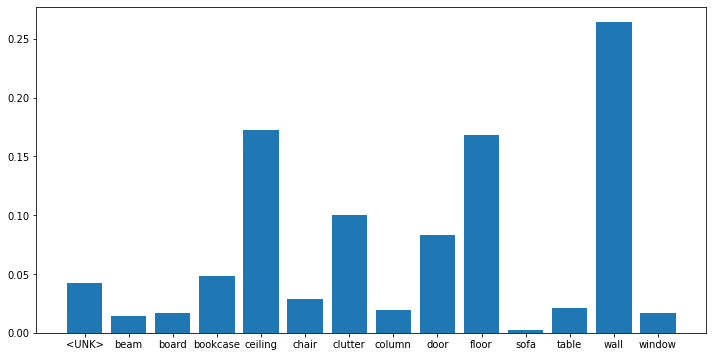

In [ ]:
fig = plt.figure(figsize=(12,6))
plt.bar(class_labels, class_histogram)
plt.show()